In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [30]:
df = pd.read_csv(r"/home/workspace/my-project/Crop_recommendation.csv")
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [31]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [32]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

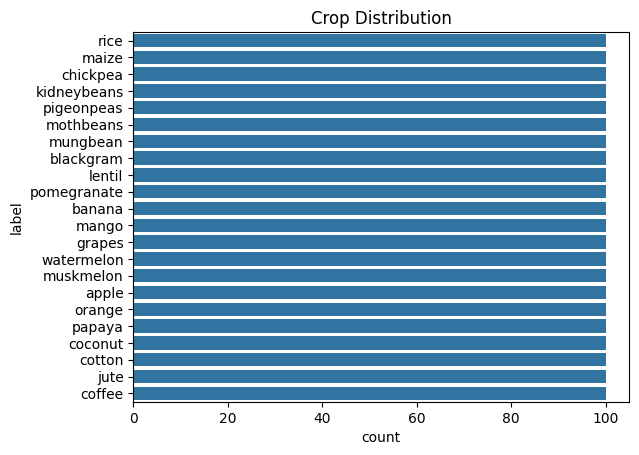

In [33]:
sns.countplot(y='label', data=df)
plt.title("Crop Distribution")
plt.show()

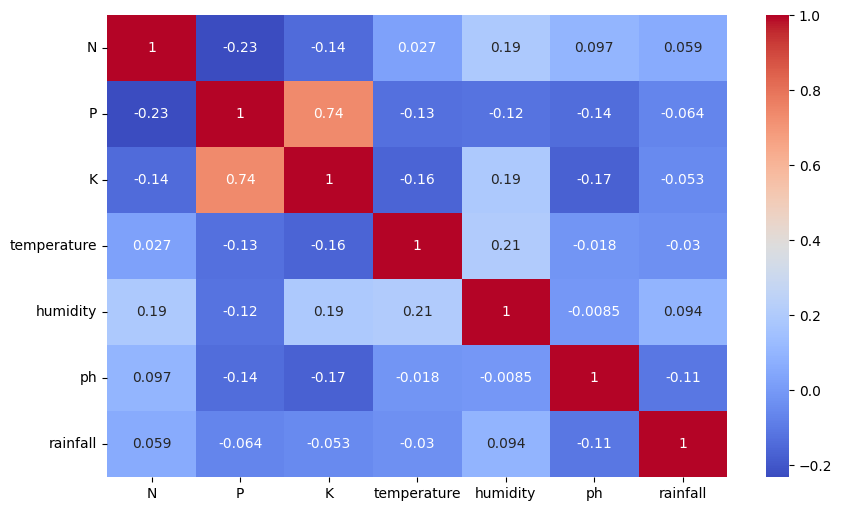

In [34]:
plt.figure(figsize=(10,6))
sns.heatmap(df.drop('label', axis=1).corr(), annot=True, cmap='coolwarm')
plt.show()

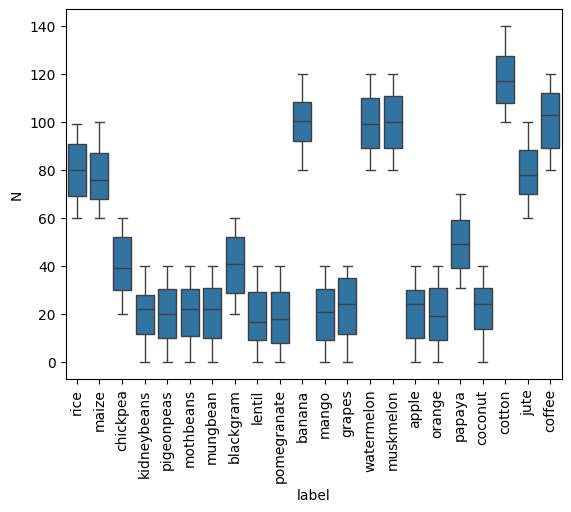

In [35]:
sns.boxplot(x='label', y='N', data=df)
plt.xticks(rotation=90)
plt.show()

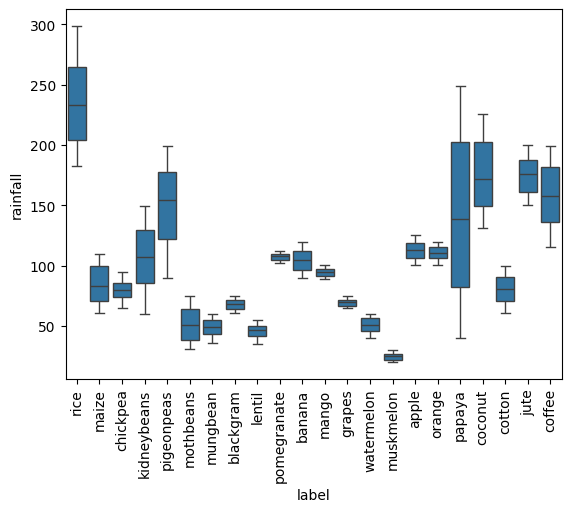

In [36]:
sns.boxplot(x='label', y='rainfall', data=df)
plt.xticks(rotation=90)
plt.show()

In [37]:
X = df.drop('label', axis=1)
y = df['label']

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [39]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [44]:
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
def predict_crop(input_data):
    input_data = np.array(input_data).reshape(1, -1)
    input_data = scaler.transform(input_data)
    
    prediction = rf.predict(input_data)
    return prediction[0]

In [45]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [46]:
import streamlit as st
import numpy as np
import pickle

model = pickle.load(open("model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))

st.title("🌱 Crop Recommendation System")

N = st.number_input("Nitrogen")
P = st.number_input("Phosphorus")
K = st.number_input("Potassium")
temp = st.number_input("Temperature")
humidity = st.number_input("Humidity")
ph = st.number_input("pH")
rainfall = st.number_input("Rainfall")

if st.button("Predict Crop"):
    data = np.array([[N, P, K, temp, humidity, ph, rainfall]])
    data = scaler.transform(data)
    
    prediction = model.predict(data)
    
    st.success(f"🌾 Recommended Crop: {prediction[0]}")

2026-04-23 12:46:56.342 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 12:46:56.377 
  command:

    streamlit run /usr/local/lib/python3.10/dist-packages/ipykernel_launcher.py [ARGUMENTS]
2026-04-23 12:46:56.378 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 12:46:56.379 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 12:46:56.380 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 12:46:56.381 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 12:46:56.382 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 12:46:56.383 Thread 'MainThread': missi